<p>
<h1><b><center></center></b></h1>
<center><img src="https://drive.google.com/uc?id=1UJc1ci41G6ahJ7ProKvunUOIBcTXZ6ZG" align="center" width="550"></center>
</p>
<h1><b><center>Mecánica Celeste</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Proyecto del Curso</center></b><h2>
<h3><b><center>Disco de acreción alrededor de un agujero negro</center></b><h3>
<h7><center><i>Última actualización del profesor</b>: Viernes 20 de marzo de 2026, 2:00 pm</i></center><h7>
</p>

## Enunciado

<center>
<img src="https://cdn.sci.news/images/2021/02/image_9386-AT2019dsg.jpg" align="center" width="100%"></center>

Muchos objetos astrofísicos fascinantes (núcleos galácticos activos, hipernovas, binarias de rayos X) pueden explicarse con los fenómenos que ocurren en los denominados discos de acreción alrededor de agujeros negros. En este proyecto usaremos lo visto en el curso de Relatividad y Gravitación para estudiar esos fenómenos.

El objetivo de este trabajo es desarrollar simulaciones, cálculos útiles, predicciones sobre el comportamiento de las partículas en un disco de acreción. La idea es poner en práctica lo visto en el curso, tanto en las partes de relatividad especial como en las de relatividad general, para estudiar estos sistemas.

## Algunas ideas

Existen muchas maneras de aplicar la teoría que veremos en el curso en este problema y no queremos sesgar tu elección de los temas o cálculos que quieras escoger para aplicarla. Sin embargo aquí van algunas ideas de cálculos que se podrían hacer:
- Simulación del movimiento de muchas partículas alrededor del agujero negro usando, inicialmente, la dinámica newtoniana.
- Cálculo y representación gráfica de la luz emitida por el disco y observada desde distinto ángulos, incluyendo los efectos de beaming y desplazamiento espectral.
- Simulación del jet del agujero negro usando partículas cargadas moviéndose en el campo del jet.
- Cálculo de la trayectoria de fotones para visualizar el disco de acreción desde distintos ángulos.
- Cálculo de las trayectorias de partículas usando la métrica de Schwarzschild y de Kerr.

## Entregables

El entregable del proyecto es **un notebook final de Jupyter** con una descripción de la teoría básica que uses, los experimentos numéricos que hayas realizado y las conclusiones a las que llegues con esos experimentos. Por supuesto puedes desarrollar otros programas y notebooks paralelos, pero se revisará el notebook con el reporte final.

Adicionalmente se deberá entregar **un repositorio de GitHub** que tenga todos los archivos, datos, notebooks, programas usados para este propósito. El notebook debe estar alojado en el repositorio.

## Criterios de evaluación

Una vez entregues el proyecto el profesor realizará una revisión del mismo y te lo devolverá con observaciones. En la segunda revisión emitirá un concepto cuantitativo del proyecto. Los criterios a evaluar serán:

- Correcta descripción y aplicación de la teoría.
- Originalidad de los experimentos numéricos.
- Conclusiones derivadas de los experimentos.
- Organización y extensión del reporte final.
- Ritmo de actualizaciones del repositorio de GitHub.

## Para tener en cuenta

- La solución presentada debe ser estrictamente individual. Evite resolver la tarea en parejas o en grupos que puede conducir a códigos o soluciones idénticos o muy similares.
- Los métodos y herramientas para resolver el problema deben ser los vistos en clase. El uso de herramientas diferentes puede ser una buena práctica en el mundo académico o laboral, pero en un curso puede también ser un indicio de un mal uso de las *asesorías* externa o del uso inapropiado de herramientas de Inteligencia Artificial (IA).
- El notebook entregado debe tener todos los resultados y gráficos, calculados y a la vista.  También debe ejecutarse completamente con `Ejecutar Todo` sin producir ningún error (verifique antes de entregar).
- El notebook debe tener explicaciones detalladas para cada paso del procedimiento usando celdas de texto. No debe poner una celda de código sin explicarla. En caso de incluir ecuaciones debe usar $\LaTeX$.

In [1]:
!pip3 install -Uq pymcel rebound einsteinpy nbformat



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
import rebound as rb
import einsteinpy.symbolic as es
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
import plotly.graph_objects as go


Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [3]:
G_SI = 6.67430e-11      # m³ kg⁻¹ s⁻²
c_SI = 299792458.0      # m/s
M_sun = 1.98847e30   # kg

In [4]:
UM = M_sun
UL = G_SI * UM / c_SI**2   # ~1476 m
UT = UL / c_SI                  # 4.925e-6 s

# En unidades relativistas
G = 1.0
C = 1.0
M = 1.0  # Masa del agujero negro en unidades solares

##### Ecuaciones de la geodésica en la métrica de Newton. Basado principalmente del notebook "3. Geodesicas de Galileo y Geodesicas de Newton"    
Ys = [T, x, y, z, Ut, Ux, Uy, Uz]

In [5]:
# Ecuación de la geodésica (Del notebook 3.)
def edg_newton(tau, Ys, G, M, c):
    T, x, y, z, Ut, Ux, Uy, Uz = Ys

    r = np.sqrt(x**2 + y**2 + z**2)

    dT_dtau = Ut
    dx_dtau = Ux
    dy_dtau = Uy
    dz_dtau = Uz

    denom = (c**2 * r - 2 * G * M) * r**2

    dUt_dtau = -2 * G * M * Ut * (x * Ux + y * Uy + z * Uz) / denom
    dUx_dtau = -(G * M * x / (c**2 * r**3)) * Ut**2
    dUy_dtau = -(G * M * y / (c**2 * r**3)) * Ut**2
    dUz_dtau = -(G * M * z / (c**2 * r**3)) * Ut**2

    return [dT_dtau, dx_dtau, dy_dtau, dz_dtau,
            dUt_dtau, dUx_dtau, dUy_dtau, dUz_dtau]

In [6]:
# Parámetros de la simulación 
N_particulas = 5000                  # <-- cambia este número

rng = np.random.default_rng(42)

r_min = 5_000e3  / UL               # 5 000 km en unidades canónicas
r_max = 30_000e3 / UL               # 30 000 km en unidades canónicas

# Coordenadas esféricas iniciales (plano ecuatorial: theta = pi/2)
r0s    = rng.uniform(r_min, r_max, N_particulas)
thetas = np.full(N_particulas, np.pi / 2)          # todas en el plano xy
phis   = rng.uniform(0, 2*np.pi,   N_particulas)

# Período kepleriano del radio medio → tiempo de integración
r_medio  = 0.5 * (r_min + r_max)
T_kepler = 2 * np.pi * np.sqrt(r_medio**3 / (G * M))
taus = np.linspace(0, 0.98 * T_kepler, 1000)

In [7]:
soluciones = []

for i in range(N_particulas):
    r0    = r0s[i]
    theta = thetas[i]
    phi   = phis[i]

    # Esféricas → cartesianas
    x0 = r0 * np.sin(theta) * np.cos(phi)
    y0 = r0 * np.sin(theta) * np.sin(phi)
    z0 = r0 * np.cos(theta)

    # Velocidad circular tangencial en el plano local (dirección azimutal)
    vc  = np.sqrt(G * M / r0)
    vx0 = -vc * np.sin(phi)
    vy0 =  vc * np.cos(phi)
    vz0 =  0.0

    # 4-velocidad inicial (igual que en el notebook)
    g00 = 1 - 2*G*M / (C**2 * r0)
    g11 = g22 = g33 = -1

    Ut0 = 1 / np.sqrt(g00 + g11*vx0**2 + g22*vy0**2 + g33*vz0**2)
    Ux0 = vx0 * Ut0 / C
    Uy0 = vy0 * Ut0 / C
    Uz0 = vz0 * Ut0 / C

    Ys0 = [0.0, x0, y0, z0, Ut0, Ux0, Uy0, Uz0]

    sol = solve_ivp(
        edg_newton,
        (taus[0], taus[-1]),
        Ys0,
        t_eval=taus,
        args=(G, M, C),
        method='Radau'
    )

    soluciones.append(sol)
    # Se puede descomentar pero es para ver cuántas particulas se están integrando por paso
    #if (i + 1) % 50 == 0:
    #    print(f"  {i+1}/{N_particulas} partículas integradas")

print("Integración completada.")

Integración completada.


#### Saquemos las soluciones que da esta simulación

In [8]:
xs_km = np.array([sol.y[1, -1] * UL / 1e3 for sol in soluciones])
ys_km = np.array([sol.y[2, -1] * UL / 1e3 for sol in soluciones])

In [9]:
radios_finales = np.sqrt(xs_km**2 + ys_km**2)
r_min_km = radios_finales.min()
r_max_km = radios_finales.max()

Esta parte de abajo se la pedí a la IA, que cosa exactamente?
Le dije a Copilot que por favor dejara la imágen en 3d de tal forma que cuando se vayan alejando las partículas del centro, éste se vaya cambiando de color para hacer "aros" (la figura de las partículas rotando en un agujero con esta métrica se ve mejor con +1000 partículas, la dejaré así pero se pueden colocar más o menos claramente)

In [10]:
cmap    = plt.cm.plasma
norm    = plt.Normalize(vmin=r_min_km, vmax=r_max_km)
colores = cmap(norm(radios_finales))

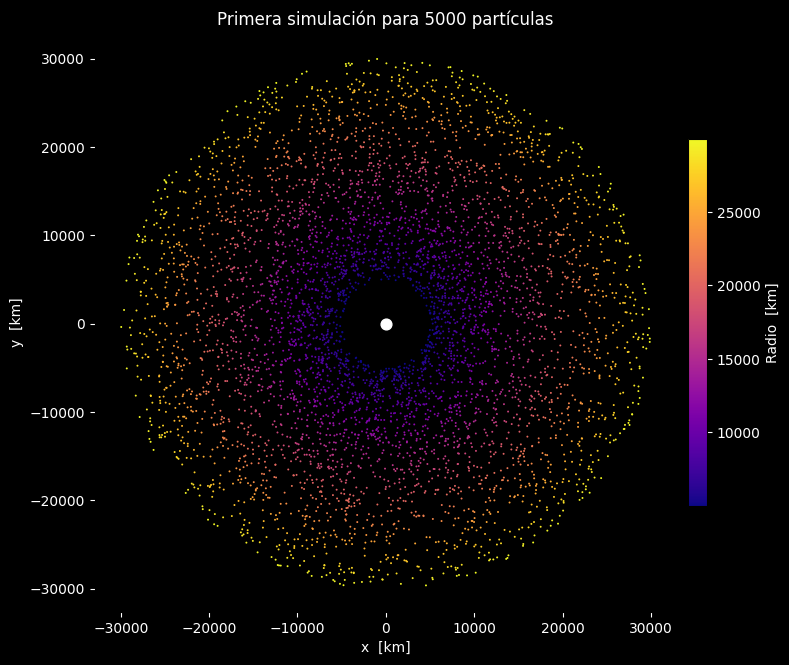

In [11]:
fig, ax = plt.subplots(figsize=(8, 8), facecolor='black')
ax.set_facecolor('black')

ax.scatter(xs_km, ys_km, c=colores, s=2, linewidths=0)
ax.scatter([0], [0], color='white', s=60, zorder=10)

sm   = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Radio  [km]', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

ax.set_xlabel('x  [km]', color='white')
ax.set_ylabel('y  [km]', color='white')
ax.set_title(f'Primera simulación para {N_particulas} partículas', color='white')
ax.tick_params(colors='white')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('geodesicas_newton_N.png', dpi=150, facecolor='black')
plt.show()

In [12]:
def beta_vec_desde_solucion(sol, frame=-1):

    Ut = sol.y[4, frame]          # U^0 = gamma
    Ux = sol.y[5, frame]          # U^1 = gamma * vx/c
    Uy = sol.y[6, frame]          # U^2 = gamma * vy/c
    Uz = sol.y[7, frame]          # U^3 = gamma * vz/c
    return np.array([Ux / Ut, Uy / Ut, Uz / Ut])

In [13]:
def aberracion_relativista(n_prima, beta_vec):

    beta2 = np.dot(beta_vec, beta_vec)
    beta  = np.sqrt(beta2)
 
    if beta < 1e-12:
        return n_prima.copy()
 
    gamma  = 1.0 / np.sqrt(1.0 - beta2)
    dot    = np.dot(beta_vec, n_prima)                 # beta · n'
    escala = (gamma - 1.0) / beta2 * dot + gamma       # factor escalar
 
    n = (n_prima + escala * beta_vec) / (gamma * (1.0 + dot))
    return n / np.linalg.norm(n)

In [14]:
def factor_doppler(n_prima, beta_vec):

    beta2 = np.dot(beta_vec, beta_vec)
    if beta2 < 1e-24:
        return 1.0
    gamma = 1.0 / np.sqrt(1.0 - beta2)
    dot   = np.dot(beta_vec, n_prima)
    return 1.0 / (gamma * (1.0 + dot))

In [15]:
def temperatura_disco(r_canon, T_inner=1e7, G=1.0, M=1.0):

    r_isco = 6.0 * G * M
    return T_inner * (r_canon / r_isco) ** (-0.75)

In [16]:
def observables_beaming(D, T_em):

    F_em  = T_em ** 4
    F_obs = D**3 * F_em
    T_obs = D * T_em
    z_dop = 1.0 / D - 1.0
    return F_obs, T_obs, z_dop

#### Hasta aquí eran funciones que necesito, unas las pillé de estelar y las otras de tú notebook y decidí explorar este camino a ver lo que salía...

In [17]:
angulos_inclinacion_deg = [0, 30, 60, 90]
 
vectores_obs = {}
for i_deg in angulos_inclinacion_deg:
    i_rad = np.deg2rad(i_deg)
    # Vector unitario hacia el observador (en el sistema del disco)
    n_obs = np.array([np.sin(i_rad), 0.0, np.cos(i_rad)])
    # n' = dirección del fotón en el marco del observador (hacia la fuente)
    vectores_obs[i_deg] = -n_obs

In [18]:
resultados = {
    i_deg: {'r_km': [], 'beta': [], 'D': [], 'F_obs': [], 'T_obs': [], 'z': []}
    for i_deg in angulos_inclinacion_deg
}
 
for sol in soluciones:
    # Radio final en unidades canónicas y en km
    x_c = sol.y[1, -1];  y_c = sol.y[2, -1];  z_c = sol.y[3, -1]
    r_c = np.sqrt(x_c**2 + y_c**2 + z_c**2)
    r_km = r_c * UL / 1e3
 
    # Temperatura de emisión en el marco propio
    T_em = temperatura_disco(r_c)
 
    # Vector beta de la partícula (igual que en el cuaderno del jet)
    bv = beta_vec_desde_solucion(sol, frame=-1)
    beta_mod = np.linalg.norm(bv)
 
    for i_deg, n_prima in vectores_obs.items(): # Esta clasificación me parece fenomenal para comparar los distintos ángulos de inclinación
        D             = factor_doppler(n_prima, bv)
        F_obs, T_obs, z = observables_beaming(D, T_em)
 
        resultados[i_deg]['r_km'].append(r_km)
        resultados[i_deg]['beta'].append(beta_mod)
        resultados[i_deg]['D'].append(D)
        resultados[i_deg]['F_obs'].append(F_obs)
        resultados[i_deg]['T_obs'].append(T_obs)
        resultados[i_deg]['z'].append(z)

In [19]:
for i_deg in angulos_inclinacion_deg:
    for key in resultados[i_deg]:
        resultados[i_deg][key] = np.array(resultados[i_deg][key])

In [20]:
xs_fin = np.array([sol.y[1, -1] * UL / 1e3 for sol in soluciones])
ys_fin = np.array([sol.y[2, -1] * UL / 1e3 for sol in soluciones])

##### Misma historia con el plot, yo genero un plot aburrido de fondo blanco y puntos azules random, pero Copilot es capaz de poner esto genial, de colores y sobre todo para poder ver los colores del efecto doppler relativista, elongación y acorte de ondas de emisión o pues podemos verlo con las partículas de luz mejor dicho, asociemos esto a lo que pertenece, que es la Luz, lo que si puedo decir es que estoy sorprendido de las ecuaciones cómo puede uno llegar a ver el fenómeno y bueno, bellamente ilustrado

In [21]:
colores_ang = {0: '#e6194b', 30: '#f58231', 60: '#4363d8', 90: '#3cb44b'}
labels_ang  = {0:  'i = 0°  (polo)',
               30: 'i = 30°',
               60: 'i = 60°',
               90: 'i = 90°  (ecuador)'}
 

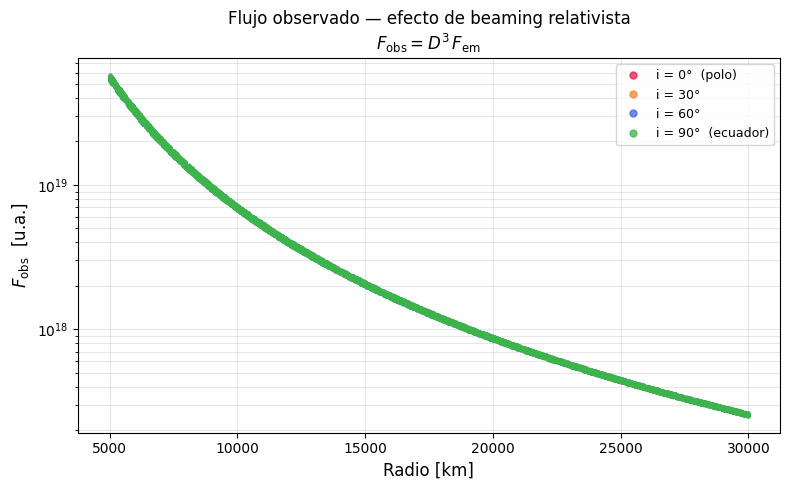

In [22]:
fig1, ax1 = plt.subplots(figsize=(8, 5))
 
for i_deg in angulos_inclinacion_deg:
    r    = resultados[i_deg]['r_km']
    Fobs = resultados[i_deg]['F_obs']
    idx  = np.argsort(r)
    ax1.semilogy(r[idx], Fobs[idx], '.', ms=4,
                 color=colores_ang[i_deg], label=labels_ang[i_deg], alpha=0.75)
 
ax1.set_xlabel('Radio [km]', fontsize=12)
ax1.set_ylabel(r'$F_\mathrm{obs}$  [u.a.]', fontsize=12)
ax1.set_title('Flujo observado — efecto de beaming relativista\n'
              r'$F_\mathrm{obs} = D^3\,F_\mathrm{em}$',
              fontsize=12)
ax1.legend(fontsize=9, markerscale=2.5)
ax1.grid(alpha=0.3, which='both')
fig1.tight_layout()
fig1.savefig('grafica2_flujo_beaming.png', dpi=150, bbox_inches='tight')
plt.show()

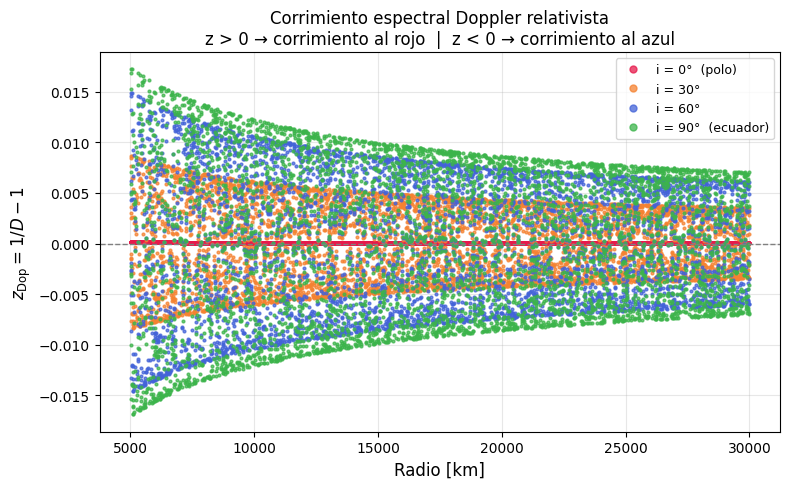

In [23]:
fig2, ax2 = plt.subplots(figsize=(8, 5))
 
for i_deg in angulos_inclinacion_deg:
    r = resultados[i_deg]['r_km']
    z = resultados[i_deg]['z']
    idx = np.argsort(r)
    ax2.plot(r[idx], z[idx], '.', ms=4,
             color=colores_ang[i_deg], label=labels_ang[i_deg], alpha=0.75)
 
ax2.axhline(0, color='gray', lw=1, ls='--')
ax2.set_xlabel('Radio [km]', fontsize=12)
ax2.set_ylabel(r'$z_\mathrm{Dop} = 1/D - 1$', fontsize=12)
ax2.set_title('Corrimiento espectral Doppler relativista\n'
              'z > 0 → corrimiento al rojo  |  z < 0 → corrimiento al azul',
              fontsize=12)
ax2.legend(fontsize=9, markerscale=2.5)
ax2.grid(alpha=0.3)
fig2.tight_layout()
fig2.savefig('grafica3_corrimiento_espectral.png', dpi=150, bbox_inches='tight')
plt.show()

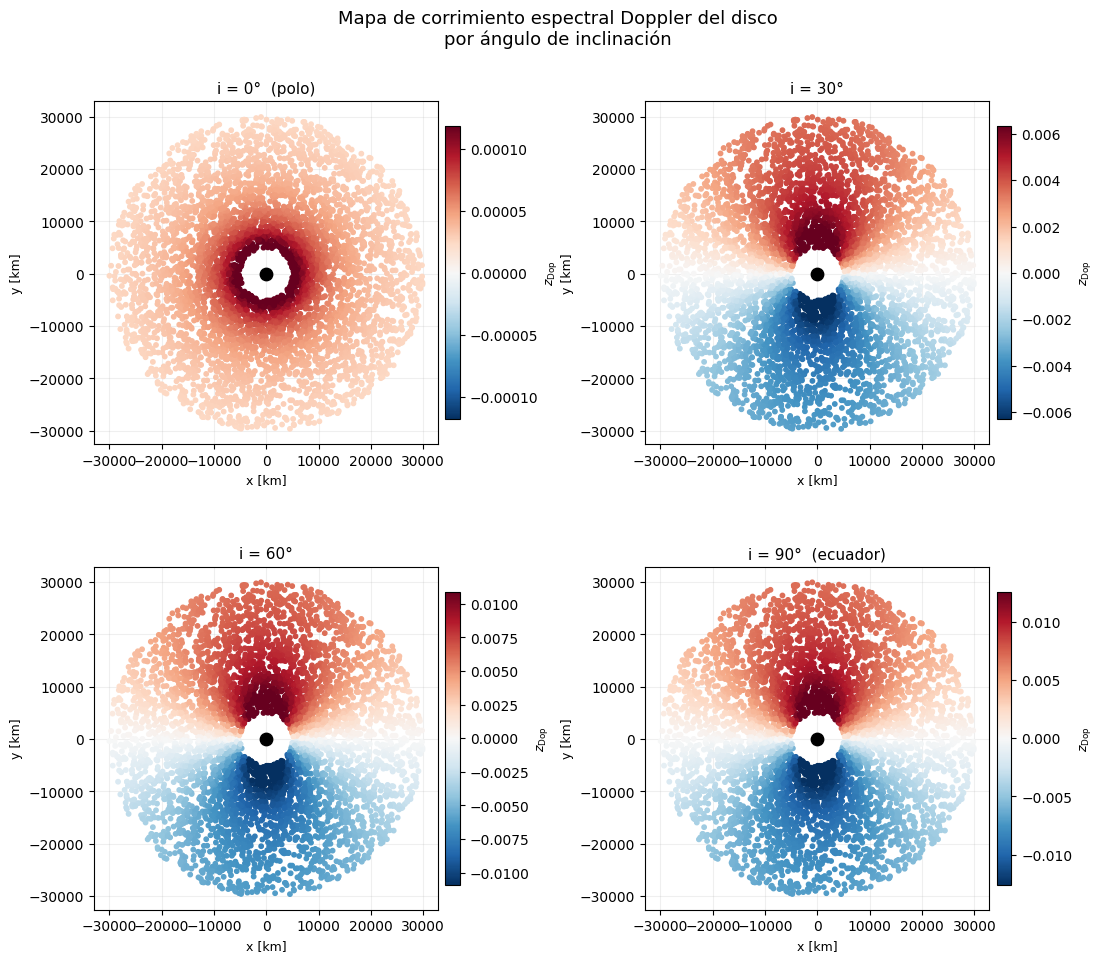

In [24]:
fig3, axes = plt.subplots(2, 2, figsize=(11, 10))
fig3.suptitle('Mapa de corrimiento espectral Doppler del disco\npor ángulo de inclinación',
              fontsize=13)
 
for ax, i_deg in zip(axes.flat, angulos_inclinacion_deg):
    z_vals = resultados[i_deg]['z']
    lim_z  = np.percentile(np.abs(z_vals), 95)
 
    sc = ax.scatter(xs_fin, ys_fin, c=z_vals, cmap='RdBu_r',
                    vmin=-lim_z, vmax=lim_z, s=10, zorder=3)
    ax.scatter(0, 0, color='black', s=80, zorder=5)
    ax.set_aspect('equal')
    ax.set_title(labels_ang[i_deg], fontsize=11)
    ax.set_xlabel('x [km]', fontsize=9)
    ax.set_ylabel('y [km]', fontsize=9)
    ax.grid(alpha=0.2)
    cbar = fig3.colorbar(sc, ax=ax, fraction=0.04, pad=0.02)
    cbar.set_label(r'$z_\mathrm{Dop}$', fontsize=9)
 
fig3.tight_layout()
fig3.savefig('grafica4_mapa_doppler.png', dpi=150, bbox_inches='tight')
plt.show()

##### Esta es una representación de datos que vi en un curso electivo y me parece genial para ilustrar datos

In [25]:
print("\n── Resumen por ángulo de inclinación ─────────────────────────────────")
print(f"{'i [°]':>6}  {'<D>':>8}  {'<F_obs>':>12}  {'<z>':>9}  {'z_max':>8}  {'z_min':>8}")
print("─" * 60)
for i_deg in angulos_inclinacion_deg:
    D    = resultados[i_deg]['D']
    Fobs = resultados[i_deg]['F_obs']
    z    = resultados[i_deg]['z']
    print(f"{i_deg:>6}  {D.mean():>8.4f}  {Fobs.mean():>12.3e}  "
          f"{z.mean():>9.5f}  {z.max():>8.5f}  {z.min():>8.5f}")


── Resumen por ángulo de inclinación ─────────────────────────────────
 i [°]       <D>       <F_obs>        <z>     z_max     z_min
────────────────────────────────────────────────────────────
     0    0.9999     5.416e+18    0.00005   0.00015   0.00002
    30    1.0000     5.423e+18    0.00003   0.00868  -0.00837
    60    1.0000     5.429e+18    0.00001   0.01492  -0.01460
    90    1.0000     5.432e+18    0.00001   0.01721  -0.01688


#### Voy a ir añadiendo el tema del jet astrofísico, definiendo primero los tensores y funciones para los campos.

In [26]:
from pymcel import constantes as const

In [27]:
UL_jet = 100e3                                          # 100 km
UM_jet = const.m_e
UT_jet = UL_jet / const.c
UF_jet = UM_jet * UL_jet / UT_jet**2
UQ_jet = UL_jet * np.sqrt(UF_jet * 4 * np.pi * const.eps0)
C      = 1

In [28]:
R_CORE = 0.05   # radio mínimo para evitar B_phi = B1/r a infinito (me daba overflow)

In [29]:
def tensor_faraday_campo_helicoidal(B0, B1, x, y, z):

    Ex = Ey = Ez = 0.0
 
    r   = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
 
    Bx = -B1 / r * np.sin(phi)
    By =  B1 / r * np.cos(phi)
    Bz =  B0
 
    F = np.array([
        [ 0,   -Ex,  -Ey,  -Ez],
        [ Ex,   0,   -Bz,   By],
        [ Ey,   Bz,   0,   -Bx],
        [ Ez,  -By,   Bx,   0 ]
    ], dtype=float)
    return F

In [30]:
def edm_relativista_jet(tau, Ys, m, q, B0, B1):

    x0, x1, x2, x3, U0, U1, U2, U3 = Ys
 
    dx0_dtau = U0
    dx1_dtau = U1
    dx2_dtau = U2
    dx3_dtau = U3
 
    F = tensor_faraday_campo_helicoidal(B0, B1, x1, x2, x3)
 
    # Covariante: U_nu = (U0, -U1, -U2, -U3)  [celda 21 del cuaderno]
    Usub = np.array([U0, -U1, -U2, -U3])
 
    f = (q / C) * F @ Usub
 
    dU0_dtau = f[0] / m
    dU1_dtau = f[1] / m
    dU2_dtau = f[2] / m
    dU3_dtau = f[3] / m
 
    return np.array([dx0_dtau, dx1_dtau, dx2_dtau, dx3_dtau,
                     dU0_dtau, dU1_dtau, dU2_dtau, dU3_dtau])

In [31]:
m_part  = 1.0    # masa (unidades m_e)
q_part  = -1.0   # carga electrón
B0      = 0.05   # campo axial
B1      = 0.05    # campo toroidal  (bajado de 3.0 → más estable)
N_jet   = 10
tau_max = 400
taus_jet = np.linspace(0, tau_max, 1500)

In [32]:
rng      = np.random.default_rng(7)
r_base   = 0.1
v_axial  = 0.8
v_giro   = 0.15
phis_jet = np.linspace(0, 2*np.pi, N_jet, endpoint=False)

In [33]:
soluciones_jet = []
for phi0 in phis_jet:
    vx = -v_giro * np.sin(phi0) + rng.normal(0, 0.01)
    vy =  v_giro * np.cos(phi0) + rng.normal(0, 0.01)
    vz =  v_axial
    v0 = np.array([vx, vy, vz])
 
    beta2 = float(np.dot(v0, v0))
    if beta2 >= 1.0:
        v0 = v0 / np.sqrt(beta2) * 0.99
        beta2 = float(np.dot(v0, v0))
 
    gamma0 = 1.0 / np.sqrt(1.0 - beta2)
    Ys0    = [0.0,
              r_base*np.cos(phi0), r_base*np.sin(phi0), 0.0,
              gamma0, gamma0*v0[0], gamma0*v0[1], gamma0*v0[2]]
 
    sol = solve_ivp(edm_relativista_jet, (0, tau_max), Ys0,
                    t_eval=taus_jet, args=(m_part, q_part, B0, B1),
                    method='Radau', rtol=1e-8, atol=1e-10)
    soluciones_jet.append(sol)
 
print(f"Integración completada — {N_jet} partículas.")

Integración completada — 10 partículas.


In [34]:
cscales = ['Viridis', 'Plasma', 'Cividis', 'Inferno', 'Magma']
trazas  = [go.Scatter3d(x=sol.y[1], y=sol.y[2], z=sol.y[3],
                        mode='lines',
                        line=dict(width=3, color=sol.y[0]/C,
                                  colorscale=cscales[k % len(cscales)]),
                        showlegend=False)
           for k, sol in enumerate(soluciones_jet)]
 
trazas.append(go.Scatter3d(x=[0], y=[0], z=[0], mode='markers',
                           marker=dict(size=8, color='white'),
                           name='Agujero negro'))
 
fig1 = go.Figure(trazas)
fig1.update_layout(
    title=f'Jet — {N_jet} partículas | B₀={B0}  B₁={B1}  v_z={v_axial}c',
    scene=dict(xaxis_title='x [100 km]', yaxis_title='y [100 km]',
               zaxis_title='z [100 km]', aspectmode='data'),
    template='plotly_dark')
fig1.show()

In [36]:
def edg_schwarzschild(tau, Ys, G, M, c):
    t, r, theta, phi, Ut, Ur, Utheta, Uphi = Ys
 
    rs = 2 * G * M / c**2  # radio de Schwarzschild
 
    dT_dtau     = Ut
    dr_dtau     = Ur
    dtheta_dtau = Utheta
    dphi_dtau   = Uphi
 

    dUt_dtau = -2 * G * M / (r * (-2 * G * M + c**2 * r)) * Ut * Ur

    dUr_dtau = (- (- G * M * (2 * G * M - c**2 * r) / (c**4 * r**3)) * Ut**2
                - G * M * (2 * G * M - c**2 * r) / (c**4 * r**3 * (1 - rs/r)**2) * Ur**2
                - (2 * G * M - c**2 * r) / c**2 * Utheta**2
                - (2 * G * M - c**2 * r) / c**2 * np.sin(theta)**2 * Uphi**2)
 
    dUtheta_dtau = (-2 / r * Ur * Utheta
                   + np.sin(theta) * np.cos(theta) * Uphi**2)
 
    dUphi_dtau = (-2 / r * Ur * Uphi
                 - 2 * np.cos(theta) / np.sin(theta) * Utheta * Uphi)
 
    return [dT_dtau, dr_dtau, dtheta_dtau, dphi_dtau,
            dUt_dtau, dUr_dtau, dUtheta_dtau, dUphi_dtau]


In [60]:
N_schw = 3000                        # cambie profe este número (10 a 50)
rng_s = np.random.default_rng(7)

#### Radios entre 10 y 60 radios de Schwarzschild (rs = 2GM/c² = 2 en unidades canónicas)

In [53]:
rs_canon = 2 * G * M / C**2         # = 2 en unidades G=M=c=1
r_min_s  = 10 * rs_canon
r_max_s  = 60 * rs_canon

#### Valores iniciales

In [54]:
r0s_s   = rng_s.uniform(r_min_s, r_max_s, N_schw)
phis_s  = rng_s.uniform(0, 2 * np.pi, N_schw)
thetas_s = np.full(N_schw, np.pi / 2)

#### Tiempo medio de integración

In [55]:
r_medio_s = 0.5 * (r_min_s + r_max_s)
T_kepler_s = 2 * np.pi * np.sqrt(r_medio_s**3 / (G * M))
taus_s = np.linspace(0, 60 * T_kepler_s, 1000)

In [56]:
soluciones_schw = []
 
for i in range(N_schw):
    r0    = r0s_s[i]
    theta0 = thetas_s[i]
    phi0  = phis_s[i]
 
    vr0    = 0.0
    vtheta0 = 0.0
    vphi0  = np.sqrt(G * M / r0) / r0   # velocidad circular azimutal (del notebook)
 
    # 4-velocidad inicial — misma normalización que el notebook
    g00 =  1 - 2*G*M / (C**2 * r0)
    g11 = -1 / (1 - 2*G*M / (C**2 * r0))
    g22 = -r0**2
    g33 = -r0**2 * np.sin(theta0)**2
 
    Ut0     = 1 / np.sqrt(g00 + g11*vr0**2 + g22*vtheta0**2 + g33*vphi0**2)
    Ur0     = vr0     * Ut0 / C
    Utheta0 = vtheta0 * Ut0 / C
    Uphi0   = vphi0   * Ut0 / C
 
    Ys0 = [0.0, r0, theta0, phi0, Ut0, Ur0, Utheta0, Uphi0]
 
    sol = solve_ivp(
        edg_schwarzschild,
        (taus_s[0], taus_s[-1]),
        Ys0,
        t_eval=taus_s,
        args=(G, M, C),
        method='Radau',
        rtol=1e-9,
        atol=1e-11
    )
    soluciones_schw.append(sol)
 
print(f"Schwarzschild: integración completada — {N_schw} partículas.")

Schwarzschild: integración completada — 3000 partículas.


In [67]:
xs_schw = np.array([
    sol.y[1, -1] * np.sin(sol.y[2, -1]) * np.cos(sol.y[3, -1]) * UL / 1e3
    for sol in soluciones_schw
])
ys_schw = np.array([
    sol.y[1, -1] * np.sin(sol.y[2, -1]) * np.sin(sol.y[3, -1]) * UL / 1e3
    for sol in soluciones_schw
])
 
radios_schw = np.sqrt(xs_schw**2 + ys_schw**2)
cmap_s  = plt.cm.plasma
norm_s  = plt.Normalize(vmin=radios_schw.min(), vmax=radios_schw.max())
colores_schw = cmap_s(norm_s(radios_schw))

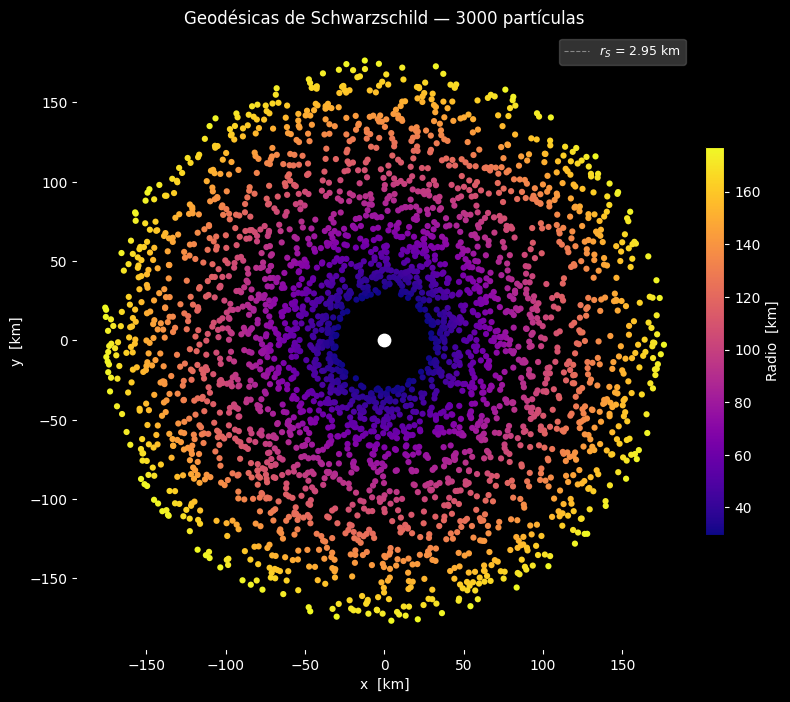

In [68]:
# ── Gráfica ───────────────────────────────────────────────────────────────────
fig_s, ax_s = plt.subplots(figsize=(8, 8), facecolor='black')
ax_s.set_facecolor('black')
 
ax_s.scatter(xs_schw, ys_schw, c=colores_schw, s=20, linewidths=0, zorder=3)
ax_s.scatter([0], [0], color='white', s=80, zorder=10)
 
# Radio de Schwarzschild (círculo de referencia)
theta_plot = np.linspace(0, 2*np.pi, 300)
rs_km = rs_canon * UL / 1e3
ax_s.plot(rs_km * np.cos(theta_plot), rs_km * np.sin(theta_plot),
          '--', color='#888888', lw=0.8, label=f'$r_S$ = {rs_km:.2f} km')
 
sm_s   = plt.cm.ScalarMappable(cmap=cmap_s, norm=norm_s)
cbar_s = fig_s.colorbar(sm_s, ax=ax_s, fraction=0.03, pad=0.02)
cbar_s.set_label('Radio  [km]', color='white')
cbar_s.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar_s.ax.yaxis.get_ticklabels(), color='white')
 
ax_s.set_xlabel('x  [km]', color='white')
ax_s.set_ylabel('y  [km]', color='white')
ax_s.set_title(f'Geodésicas de Schwarzschild — {N_schw} partículas', color='white')
ax_s.tick_params(colors='white')
ax_s.legend(labelcolor='white', framealpha=0.2, fontsize=9)
ax_s.set_aspect('equal')
plt.tight_layout()
plt.savefig('geodesicas_schwarzschild_N.png', dpi=150, facecolor='black')
plt.show()